## Laboratorio 3: Detección de malware

Primero vamos a determinar si los archivos están empaquetados

In [1]:
import pefile
import os
import subprocess
import pandas as pd
import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from google import genai
from dotenv import load_dotenv
from google.genai import types
from sklearn.decomposition import PCA
import itertools
import networkx
from sklearn.preprocessing import normalize
import argparse
from networkx.drawing.nx_pydot import write_dot
import itertools
import pprint


In [13]:
def show_sections(pefile_object):
    for section in pefile_object.sections:
        print("Nombre:", section.Name)
        print("VirtualAddress:", hex(section.VirtualAddress))
        print("Size:", section.SizeOfRawData)
        print("-" * 20)


carpeta = "MALWR"
archivos_procesados = 0

for archivo in os.listdir(carpeta):
    ruta = os.path.join(carpeta, archivo)

    # Solo archivos normales
    if os.path.isfile(ruta):
        try:
            print("\n" + "="*60)
            print(f"Analizando: {archivo}")
            print("="*60)

            pe = pefile.PE(ruta)
            show_sections(pe)

            archivos_procesados += 1

            if archivos_procesados >= 5:
                break

        except Exception as e:
            print(f"No es un PE válido: {archivo}")

if archivos_procesados == 0:
    print("No se encontraron ejecutables PE válidos.")



Analizando: F6655E39465C2FF5B016980D918EA028
Nombre: b'UPX0\x00\x00\x00\x00'
VirtualAddress: 0x1000
Size: 0
--------------------
Nombre: b'UPX1\x00\x00\x00\x00'
VirtualAddress: 0x6000
Size: 3584
--------------------
Nombre: b'.rsrc\x00\x00\x00'
VirtualAddress: 0x7000
Size: 512
--------------------

Analizando: FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2
Nombre: b'UPX0\x00\x00\x00\x00'
VirtualAddress: 0x1000
Size: 0
--------------------
Nombre: b'UPX1\x00\x00\x00\x00'
VirtualAddress: 0x6000
Size: 4096
--------------------
Nombre: b'.rsrc\x00\x00\x00'
VirtualAddress: 0x7000
Size: 512
--------------------

Analizando: 65018CD542145A3792BA09985734C12A
Nombre: b'UPX0\x00\x00\x00\x00'
VirtualAddress: 0x1000
Size: 0
--------------------
Nombre: b'UPX1\x00\x00\x00\x00'
VirtualAddress: 0x6000
Size: 4096
--------------------
Nombre: b'.rsrc\x00\x00\x00'
VirtualAddress: 0x7000
Size: 512
--------------------

Analizando: 6FAA4740F99408D4D2DDDD0B09BBDEFD
Nombre: b'UPX0\x00\x00\x00\x00'
VirtualAddress

Vemos que si están empaquetados, vamos a desempaquetarlos

In [14]:
for file in os.listdir('MALWR'):
    route = os.path.join('MALWR', file)
    result = subprocess.run(['upx', '-d', route], capture_output=True, text=True)

    if result.returncode == 0:
        print(f' {file} comprimido')
    else:
        print(f'{file} falló: {result.stderr}')

 F6655E39465C2FF5B016980D918EA028 comprimido
 FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2 comprimido
 65018CD542145A3792BA09985734C12A comprimido
 6FAA4740F99408D4D2DDDD0B09BBDEFD comprimido
 F8437E44748D2C3FCF84019766F4E6DC comprimido
 B98hX8E8622C393D7E832D39E620EAD5D3B49 comprimido
SAM_B659D71AE168E774FAAF38DB30F4A84 falló: upx: MALWR/SAM_B659D71AE168E774FAAF38DB30F4A84: NotPackedException: not packed by UPX

POL55_A4F1ECC4D25B33395196B5D51A06790 falló: upx: MALWR/POL55_A4F1ECC4D25B33395196B5D51A06790: NotPackedException: not packed by UPX

 BVJ2D9FBF759F527AF373E34673DC3ACA462 comprimido
 AAAz2E1B6940985A23E5639450F8391820655 comprimido
 VBMM9_149B7BD7218AAB4E257D28469FDDB0D comprimido
 NBV_8B75BCBFF174C25A0161F30758509A44 comprimido
 TG78Z__727A6800991EEAD454E53E8AF164A99C comprimido
 RTC_7F85D7F628CE62D1D8F7B39D8940472 comprimido
 B07322743778B5868475DBE66EEDAC4F comprimido
 AL65_DB05DF0498B59B42A8E493CF3C10C578 comprimido
 JKK8CA6FE7A1315AF5AFEAC2961460A80569 comprimido
 FHHH6576C1

Ya desempaquetados, vamos a crear el dataset, este tendrá estas características:

- Hash del archivop
- Imports
- Timestamp de compliación


In [15]:
def get_imports(path):
    """
    Extract function calls from header
    """
    imports = set()
    timestamp = None
    try:
        pe = pefile.PE(path)
        timestamp = pe.FILE_HEADER.TimeDateStamp

        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                dll = entry.dll.decode(errors="ignore")

                for imp in entry.imports:
                    if imp.name:
                        func = imp.name.decode(errors="ignore")
                        imports.add(f"{dll}:{func}")

    except pefile.PEFormatError:
        return set(), None

    except Exception:
        return set(), None

    return imports, timestamp


df =  pd.DataFrame(columns=['hash', 'imports', 'timestamp'])

for file in os.listdir('MALWR'):
    route = os.path.join('MALWR', file)
    imports, timestamp = get_imports(route)

    imports = ' '.join(list(imports))

    new_row = pd.DataFrame([{'hash': file, 'imports': imports, 'timestamp': timestamp }])

    df = pd.concat([df, new_row], ignore_index=True)

    if result.returncode == 0:
        print(f' {file} comprimido')
    else:
        print(f'{file} falló: {result.stderr}')


df.to_csv('raw_data.csv')

 F6655E39465C2FF5B016980D918EA028 comprimido
 FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2 comprimido
 65018CD542145A3792BA09985734C12A comprimido
 6FAA4740F99408D4D2DDDD0B09BBDEFD comprimido
 F8437E44748D2C3FCF84019766F4E6DC comprimido
 B98hX8E8622C393D7E832D39E620EAD5D3B49 comprimido
 SAM_B659D71AE168E774FAAF38DB30F4A84 comprimido
 POL55_A4F1ECC4D25B33395196B5D51A06790 comprimido
 BVJ2D9FBF759F527AF373E34673DC3ACA462 comprimido
 AAAz2E1B6940985A23E5639450F8391820655 comprimido
 VBMM9_149B7BD7218AAB4E257D28469FDDB0D comprimido
 NBV_8B75BCBFF174C25A0161F30758509A44 comprimido
 TG78Z__727A6800991EEAD454E53E8AF164A99C comprimido
 RTC_7F85D7F628CE62D1D8F7B39D8940472 comprimido
 B07322743778B5868475DBE66EEDAC4F comprimido
 AL65_DB05DF0498B59B42A8E493CF3C10C578 comprimido
 JKK8CA6FE7A1315AF5AFEAC2961460A80569 comprimido
 FHHH6576C196385407B0F7F4B1B537D88983 comprimido
 785003A405BC7A4EBCBB21DDB757BF3F comprimido
 L11_1415EB8519D13328091CC5C76A624E3D comprimido
 FTTR9EA3C16194CE354C244C1B74C46CD

## Preprocesamiento

Vamos a usar TF-IDF para convertir la secuencia de imports a vectores

In [17]:
df_malware = pd.read_csv('raw_data.csv', index_col = 0)

print('Numero de filas: ', df_malware.shape[0])


Numero de filas:  41


In [18]:
df_malware.isna().sum()

hash         0
imports      1
timestamp    1
dtype: int64

Vemos que tenemos un archivo del cuál no hay ni imports ni timestamp, vamos a borrarlo pues la forma en la que pensamos analizar el malware es en base a los imports en la sección del header.

In [19]:
df_malware = df_malware.dropna(subset=['imports'])

df_malware.isna().sum()

hash         0
imports      0
timestamp    0
dtype: int64

In [20]:
def count_unique_imports(df, column="imports"):
    unique_imports = set()

    for row in df[column].dropna():
        imports = row.split()
        unique_imports.update(imports)

    return len(unique_imports), unique_imports

n_imports, imports_set = count_unique_imports(df_malware)

print("Número de imports únicos:", n_imports)

Número de imports únicos: 393


Y ahora vamos a vectorizar con TF-IDF

In [21]:
tfidf_vectorizer = TfidfVectorizer()

corpus = list(df_malware['imports'])

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

df_new = pd.DataFrame({
    'Hash': df_malware['hash'],
    'Imports': list(tfidf_matrix.toarray()),
    'Timestamp': df_malware['timestamp']
})

print(df_new.head())



                                       Hash  \
0          F6655E39465C2FF5B016980D918EA028   
1  FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2   
2          65018CD542145A3792BA09985734C12A   
3          6FAA4740F99408D4D2DDDD0B09BBDEFD   
4          F8437E44748D2C3FCF84019766F4E6DC   

                                             Imports     Timestamp  
0  [0.0, 0.0, 0.0, 0.018760568151320794, 0.0, 0.0...  1.263576e+09  
1  [0.0, 0.0, 0.0, 0.01541050895825756, 0.0, 0.01...  1.242321e+09  
2  [0.0, 0.0, 0.0, 0.01541050895825756, 0.0, 0.01...  1.195430e+09  
3  [0.0, 0.0, 0.0, 0.01541050895825756, 0.0, 0.01...  1.242321e+09  
4  [0.0, 0.0, 0.0, 0.01541050895825756, 0.0, 0.01...  1.242321e+09  


In [22]:
df_new.to_csv('transformed.csv')

# Parte 2 – Clustering
Cargamos el dataset transformado y reconstruimos la matriz de features numérica.

In [9]:
df = pd.read_csv('transformed.csv', index_col=0)

def parse_imports(s):
    cleaned = re.sub(r'\s+', ' ', s.strip().strip('[]'))
    return np.array([float(x) for x in cleaned.split()])

X_imports = np.vstack(df['Imports'].apply(parse_imports).values)

# Normalizar timestamp y combinarlo con los vectores TF-IDF
ts = df['Timestamp'].fillna(df['Timestamp'].median()).values.reshape(-1, 1)
ts_norm = StandardScaler().fit_transform(ts)

X = np.hstack([X_imports, ts_norm])

X_scaled = StandardScaler().fit_transform(X)

print('Shape de la matriz de features:', X_scaled.shape)


Shape de la matriz de features: (40, 361)


Metodo del codo


Calculamos la inercia (WCSS) para K-means y el costo para K-medoids en un rango de K. El codo indica el punto donde agregar más clústeres ya no aporta una mejora significativa.

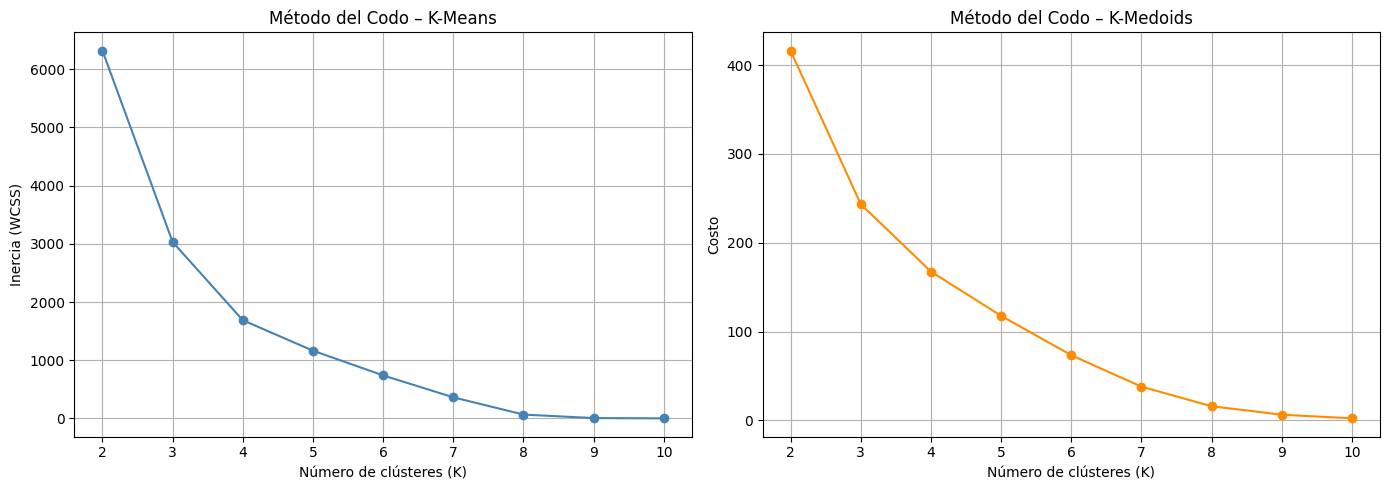

Gráfica guardada como elbow_plot.png


In [10]:
K_range = range(2, 11)

# K-means: inercia
inertias_km = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias_km.append(km.inertia_)

# K-medoids: costo
costs_kmed = []
k_valid_elbow = []
for k in K_range:
    kmed = KMedoids(
        n_clusters=k,
        metric='euclidean',
        method='pam',
        init='k-medoids++',
        random_state=42,
        max_iter=500
    )
    labels = kmed.fit_predict(X_scaled)
    unique_labels = np.unique(labels)
    if len(unique_labels) < k:
        print(f"K={k}: solo {len(unique_labels)} clústeres generados, omitiendo...")
        continue
    costs_kmed.append(kmed.inertia_)
    k_valid_elbow.append(k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias_km, marker='o', color='steelblue')
axes[0].set_title('Método del Codo – K-Means')
axes[0].set_xlabel('Número de clústeres (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].grid(True)

axes[1].plot(k_valid_elbow, costs_kmed, marker='o', color='darkorange')
axes[1].set_title('Método del Codo – K-Medoids')
axes[1].set_xlabel('Número de clústeres (K)')
axes[1].set_ylabel('Costo')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print('Gráfica guardada como elbow_plot.png')

Coeficiente de Silhouette


El Silhouette mide qué tan bien separados están los clústeres (valores cercanos a 1 = mejor). Lo graficamos para cada K y determinamos el K óptimo.

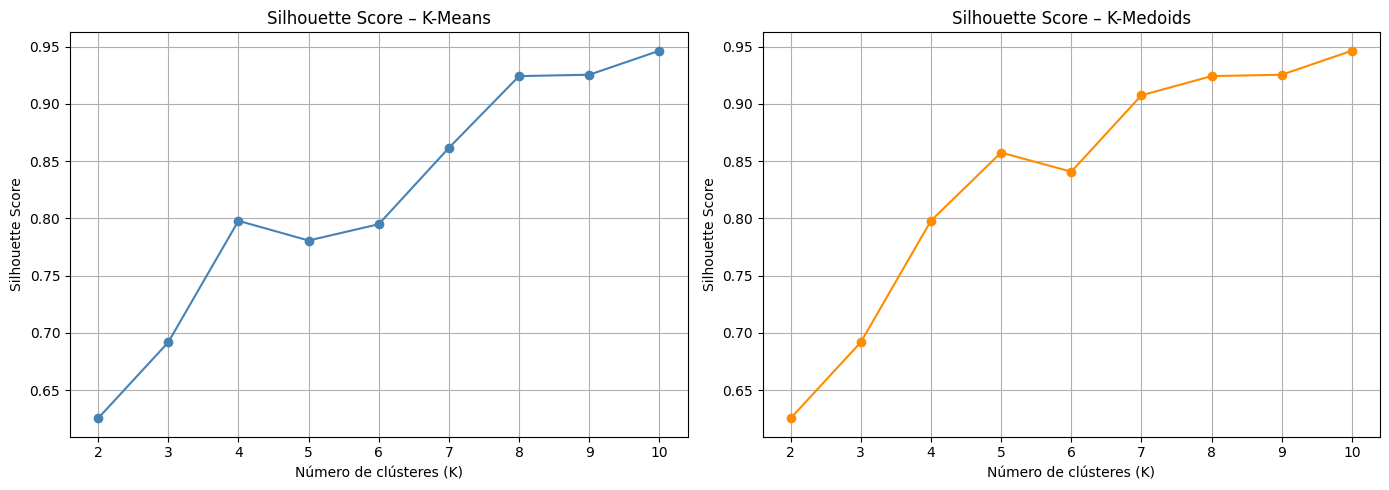

K óptimo K-Means   (Silhouette): 10  → score: 0.9463
K óptimo K-Medoids (Silhouette): 10 → score: 0.9463


In [11]:
sil_km   = []
sil_kmed = []
k_valid_sil = []

for k in K_range:
    # K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    sil_km.append(silhouette_score(X_scaled, labels_km))

    # K-Medoids
    kmed = KMedoids(
        n_clusters=k,
        metric='euclidean',
        method='pam',
        init='k-medoids++',
        random_state=42,
        max_iter=500
    )
    labels_kmed = kmed.fit_predict(X_scaled)
    unique_labels = np.unique(labels_kmed)
    if len(unique_labels) < k:
        print(f"K={k}: solo {len(unique_labels)} clústeres, omitiendo Silhouette...")
        continue
    sil_kmed.append(silhouette_score(X_scaled, labels_kmed))
    k_valid_sil.append(k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), sil_km, marker='o', color='steelblue')
axes[0].set_title('Silhouette Score – K-Means')
axes[0].set_xlabel('Número de clústeres (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True)

axes[1].plot(k_valid_sil, sil_kmed, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score – K-Medoids')
axes[1].set_xlabel('Número de clústeres (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150)
plt.show()

k_opt_km   = list(K_range)[np.argmax(sil_km)]
k_opt_kmed = k_valid_sil[np.argmax(sil_kmed)] if sil_kmed else k_opt_km

print(f'K óptimo K-Means   (Silhouette): {k_opt_km}  → score: {max(sil_km):.4f}')
print(f'K óptimo K-Medoids (Silhouette): {k_opt_kmed} → score: {max(sil_kmed):.4f}')

Etiquetado


Usamos el K óptimo determinado por Silhouette para etiquetar cada muestra de malware.

In [12]:
K_FINAL = k_opt_km

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
kmed_final = KMedoids(
    n_clusters=k_opt_kmed,
    metric='euclidean',
    method='pam',
    init='k-medoids++',
    random_state=42,
    max_iter=500
)

df['cluster_kmeans']   = km_final.fit_predict(X_scaled)
df['cluster_kmedoids'] = kmed_final.fit_predict(X_scaled)

print(df[['Hash', 'cluster_kmeans', 'cluster_kmedoids']].to_string())

df.to_csv('labeled.csv')
print('\nDataset etiquetado guardado como labeled.csv')

                                        Hash  cluster_kmeans  cluster_kmedoids
0           F6655E39465C2FF5B016980D918EA028               0                 7
1   FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2               9                 1
2           65018CD542145A3792BA09985734C12A               3                 9
3           6FAA4740F99408D4D2DDDD0B09BBDEFD               9                 1
4           F8437E44748D2C3FCF84019766F4E6DC               9                 1
5      B98hX8E8622C393D7E832D39E620EAD5D3B49               8                 8
6        SAM_B659D71AE168E774FAAF38DB30F4A84               2                 0
7      POL55_A4F1ECC4D25B33395196B5D51A06790               2                 0
8       BVJ2D9FBF759F527AF373E34673DC3ACA462               9                 1
9      AAAz2E1B6940985A23E5639450F8391820655               1                 2
10     VBMM9_149B7BD7218AAB4E257D28469FDDB0D               4                 3
11      NBV_8B75BCBFF174C25A0161F30758509A44        

Ya que hemos etiquetado cada malware, vamos a visualizar los clusters en 2D, para ello vamos a reducir la dimensionalidad usando PCA

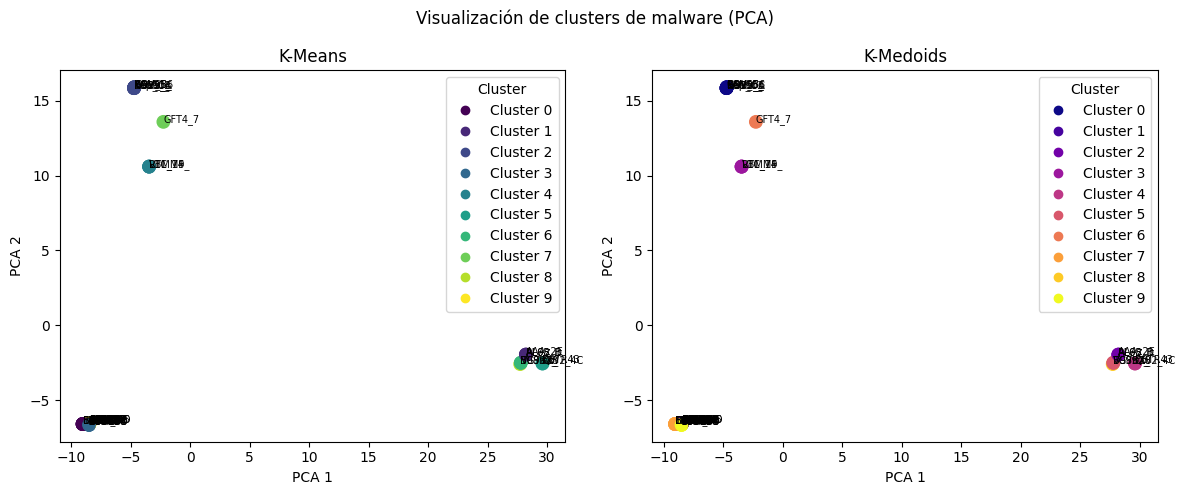

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(1,2, figsize=(12,5))

# ---------- KMEANS ----------
scatter1 = ax[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster_kmeans"],
    cmap="viridis",
    s=80
)

ax[0].set_title("K-Means")
ax[0].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2")

for i, txt in enumerate(df["Hash"]):
    ax[0].annotate(txt[:6], (X_pca[i,0], X_pca[i,1]), fontsize=7)

# crear leyenda por cluster
clusters = np.unique(df["cluster_kmeans"])
handles = [
    plt.Line2D([], [], marker="o", linestyle="", 
               color=scatter1.cmap(scatter1.norm(c)), 
               label=f"Cluster {c}")
    for c in clusters
]
ax[0].legend(handles=handles, title="Cluster")


# ---------- KMEDOIDS ----------
scatter2 = ax[1].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster_kmedoids"],
    cmap="plasma",
    s=80
)

ax[1].set_title("K-Medoids")
ax[1].set_xlabel("PCA 1")
ax[1].set_ylabel("PCA 2")

for i, txt in enumerate(df["Hash"]):
    ax[1].annotate(txt[:6], (X_pca[i,0], X_pca[i,1]), fontsize=7)

clusters2 = np.unique(df["cluster_kmedoids"])
handles2 = [
    plt.Line2D([], [], marker="o", linestyle="", 
               color=scatter2.cmap(scatter2.norm(c)), 
               label=f"Cluster {c}")
    for c in clusters2
]
ax[1].legend(handles=handles2, title="Cluster")

plt.suptitle("Visualización de clusters de malware (PCA)")
plt.tight_layout()
plt.show()

## Clustering con embeddings

Ahora vamos a usar embeddings para hacer clustering e identificar familias de malware

In [ ]:
load_dotenv()

api_key = os.environ.get("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=list(df_malware['imports']),
        config=types.EmbedContentConfig(task_type="CLUSTERING")
)

embeddings = np.array([e.values for e in result.embeddings])

embeddings_norm = normalize(embeddings)

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_norm)

df_embedded = pd.DataFrame({
    'Hash': df_malware['hash'],
    'X': embeddings_2d[:, 0],
    'Y': embeddings_2d[:, 1]})



In [2]:
df_final = pd.read_csv('embeddings.csv')
df_label = pd.read_csv('labeled.csv')

df_final['clusterKNN'] = df_label['cluster_kmeans']
df_final['cluster_kmedoids'] = df_label['cluster_kmedoids']

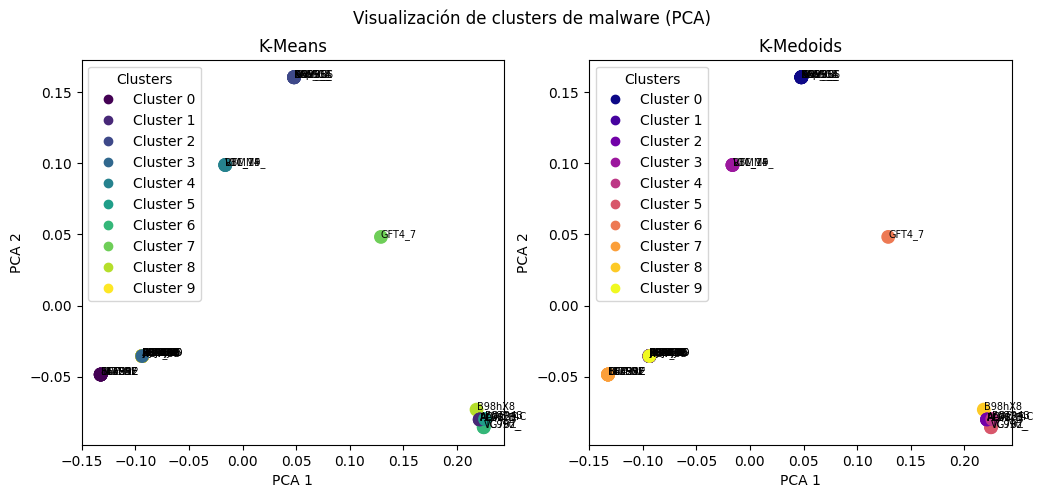

In [15]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

scatter1 = ax[0].scatter(df_final["X"], df_final["Y"], c=df_final["clusterKNN"], cmap="viridis", s=80)
ax[0].set_title("K-Means")
ax[0].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2")

for i, txt in enumerate(df_final["Hash"]):
    ax[0].annotate(txt[:6], (df_final["X"].iloc[i], df_final["Y"].iloc[i]), fontsize=7)



clusters = np.unique(df_final["clusterKNN"])
handles = [
    plt.Line2D([], [], marker="o", linestyle="", 
               color=scatter1.cmap(scatter1.norm(c)),
               label=f"Cluster {c}")
    for c in clusters
]
ax[0].legend(handles=handles, title="Clusters")


scatter2 = ax[1].scatter(df_final["X"], df_final["Y"], c=df_final["cluster_kmedoids"], cmap="plasma", s=80)
ax[1].set_title("K-Medoids")
ax[1].set_xlabel("PCA 1")
ax[1].set_ylabel("PCA 2")

for i, txt in enumerate(df_final["Hash"]):
    ax[1].annotate(txt[:6], (df_final["X"].iloc[i], df_final["Y"].iloc[i]), fontsize=7)


clusters2 = np.unique(df_final["cluster_kmedoids"])
handles2 = [
    plt.Line2D([], [], marker="o", linestyle="", 
               color=scatter2.cmap(scatter2.norm(c)),
               label=f"Cluster {c}")
    for c in clusters2
]
ax[1].legend(handles=handles2, title="Clusters")

plt.suptitle("Visualización de clusters de malware (PCA)")
plt.show()

## Jaccard

In [61]:
def get_imports(path):
    """
    Extract function calls from header
    """
    imports = set()
    try:
        pe = pefile.PE(path)

        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                dll = entry.dll.decode(errors="ignore")

                for imp in entry.imports:
                    if imp.name:
                        func = imp.name.decode(errors="ignore")
                        imports.add(f"{dll}:{func}")

    except pefile.PEFormatError:
        # No es un PE válido
        return set()

    except Exception:
        return set()

    return imports

def jaccard(set1,set2):
    """
    Compute the Jaccard distance between two sets by taking
    their intersection, union and then dividing the number
    of elements in the intersection by the number of elements
    in their union.
    """
    intersection = set1.intersection(set2)
    intersection_length = float(len(intersection))
    union = set1.union(set2)
    union_length = float(len(union))
    return intersection_length / union_length

def getstrings(fullpath):
    """
    Extract strings from the binary indicated by the 'fullpath'
    parameter, and then return the set of unique strings in
    the binary.
    """
    strings = os.popen("strings '{0}'".format(fullpath)).read()
    strings = set(strings.split("\n"))
    return strings

def pecheck(fullpath):
    """
    Do a cursory sanity check to make sure 'fullpath' is
    a Windows PE executable (PE executables start with the
    two bytes 'MZ')
    """
    return open(fullpath).read(2) == "MZ"

def feature_analysis(malware_dir, output_file_dot, umbral):
    
    malware_paths = [] # where we'll store the malware file paths
    malware_attributes = dict() # where we'll store the malware strings
    graph = networkx.Graph() # the similarity graph

    for root, dirs, paths in os.walk(malware_dir):
        # walk the target directory tree and store all of the file paths
        for path in paths:
            full_path = os.path.join(root,path)
            malware_paths.append(full_path)

    # filter out any paths that aren't PE files
    #malware_paths = filter(pecheck, malware_paths)

    # get and store the strings for all of the malware PE files
    for path in malware_paths:

        strings = getstrings(path)

        imports = get_imports(path)
        attributes = imports.union(strings)
        malware_attributes[path] = attributes
        # add each malware file to the graph
        graph.add_node(path,label=os.path.split(path)[-1][:10])

    # iterate through all pairs of malware
    for malware1,malware2 in itertools.combinations(malware_paths,2):

        # compute the jaccard distance for the current pair
        jaccard_index = jaccard(malware_attributes[malware1],malware_attributes[malware2])

        # if the jaccard distance is above the threshold add an edge
        if jaccard_index > umbral:
            graph.add_edge(malware1,malware2,penwidth=1+(jaccard_index-umbral)*10)

    # write the graph to disk so we can visualize it
    write_dot(graph,output_file_dot)


In [62]:
feature_analysis('./MALWR', 'imgs/output_header_06.dot', 0.6)

In [63]:
feature_analysis('./MALWR', 'imgs/output_header_09.dot', 0.9)

In [64]:
feature_analysis('./MALWR', 'imgs/output_header_095.dot', 0.95)